# NTK vs squared distance: training image → noised image

**Hypothesis:** The (input-space) neural tangent kernel from a training image to a noised image behaves like

$$K(x_{\mathrm{train}}, x_{\mathrm{noised}}) \propto \exp(-\beta \|x_{\mathrm{train}} - x_{\mathrm{noised}}\|^2)$$

So we plot **log(kernel)** vs **squared distance** and expect a linear relationship with slope \(-\beta\).

We use the **input-gradient kernel** (gradient of the score at a single pixel w.r.t. input):
\(K(x,x') = \langle \nabla_x f(x), \nabla_x f(x') \rangle\) where \(f\) is the scalar score at a fixed pixel.

In [2]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt

ROOT = Path(os.path.abspath("")).resolve().parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.models import DDIM
from src.utils.data import get_dataset
from src.utils.noise_schedules import cosine_noise_schedule
from src.utils.channel_theory import load_scale_calibration

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Training loss curve

Evaluate loss (MSE between predicted and true noise) on a fixed subset for checkpoints every 10 epochs starting from epoch 39.

Epochs to evaluate for loss curve: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500]
Files already downloaded and verified
Epoch 0: loss = 0.0895
Epoch 10: loss = 0.0732
Epoch 20: loss = 0.0685
Epoch 30: loss = 0.0735
Epoch 40: loss = 0.0709
Epoch 50: loss = 0.0679
Epoch 60: loss = 0.0588
Epoch 70: loss = 0.0687
Epoch 80: loss = 0.0627
Epoch 90: loss = 0.0561
Epoch 100: loss = 0.0558
Epoch 110: loss = 0.0651
Epoch 120: loss = 0.0702
Epoch 130: loss = 0.0670
Epoch 140: loss = 0.0649
Epoch 150: loss = 0.0668
Epoch 160: loss = 0.0720
Epoch 170: loss = 0.0616
Epoch 180: loss = 0.0605
Epoch 190: loss = 0.0709
Epoch 200: loss = 0.0648
Epoch 210: loss = 0.0634
Epoch 220: loss = 0.0659
Epoch 230: loss = 0.0744
Epoch 240: loss = 0.0668
Epoch 250: loss = 0.0623
Epoch 260: loss = 0.0697
Epoch 270: loss = 

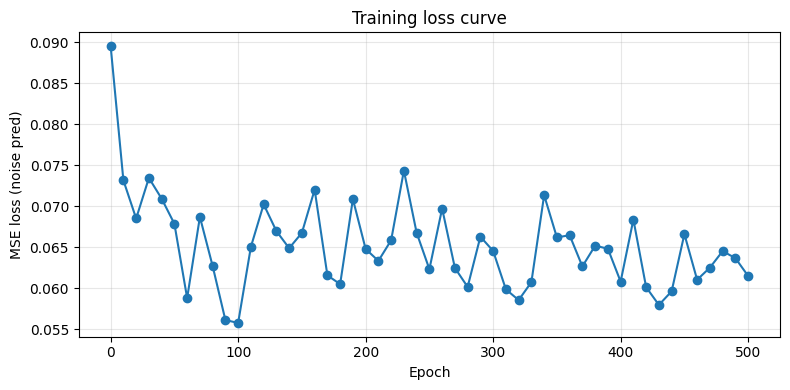

In [3]:
import re
from torch.nn.functional import mse_loss

checkpoint_stem = "backbone_CelebA_ResNet"
dataset_name = "celeba"
ckpt_dir = ROOT / "checkpoints"

# Epochs to evaluate: every 10 starting from 39 (39, 49, 59, ...)
available_epochs = []
for f in ckpt_dir.glob(f"{checkpoint_stem}_epoch*.pt"):
    m = re.search(r"_epoch(\d+)\.pt$", f.name)
    if m:
        available_epochs.append(int(m.group(1)))
available_epochs = sorted(set(available_epochs))
epochs_to_eval = [e for e in available_epochs if e % 10 == 0]
if not epochs_to_eval:
    epochs_to_eval = [e for e in available_epochs if e % 10 == 0]  # fallback: 0, 10, 20, ...
print("Epochs to evaluate for loss curve:", epochs_to_eval)

train_set, _ = get_dataset(dataset_name, root=str(ROOT / "data"), train=True)
n_eval = min(500, len(train_set))
torch.manual_seed(123)
eval_idx = torch.randperm(len(train_set))[:n_eval]
max_t = 1000  # same as training

losses = []
epochs_plotted = []
for ep in epochs_to_eval:
    ckpt_path = ckpt_dir / f"{checkpoint_stem}_epoch{ep}.pt"
    if not ckpt_path.exists():
        continue
    model_eval = torch.load(str(ckpt_path), map_location=device, weights_only=False)
    model_eval.to(device).eval()
    total_loss = 0.0
    n_batches = 0
    with torch.no_grad():
        for start in range(0, n_eval, 32):
            end = min(start + 32, n_eval)
            images = torch.stack([train_set[eval_idx[i].item()][0] for i in range(start, end)]).to(device)
            batch_size = images.shape[0]
            t = torch.randint(0, max_t, (batch_size,), device=device).float() / max_t
            beta_t = cosine_noise_schedule(t)
            noise = torch.randn_like(images, device=device)
            noised = torch.sqrt(1 - beta_t)[:, None, None, None] * images + torch.sqrt(beta_t)[:, None, None, None] * noise
            pred = model_eval(t, noised)
            total_loss += mse_loss(pred, noise).item() * batch_size
            n_batches += 1
    mean_loss = total_loss / n_eval
    losses.append(mean_loss)
    epochs_plotted.append(ep)
    print(f"Epoch {ep}: loss = {mean_loss:.4f}")
    del model_eval
    if device.type == "cuda":
        torch.cuda.empty_cache()

plt.figure(figsize=(8, 4))
plt.plot(epochs_plotted, losses, "o-")
plt.xlabel("Epoch")
plt.ylabel("MSE loss (noise pred)")
plt.title("Training loss curve")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Helpers: gradient at single pixel, noising, distances

In [4]:
def grad_score_single_pixel(model, x, t_scalar, pixel_i, pixel_j, channel_mode="mean"):
    """
    x: (1, C, H, W), requires_grad.
    Returns ∇_x f(x) flattened, where f is score at (pixel_i, pixel_j) (mean over channels).
    """
    x = x.to(device)
    if not x.requires_grad:
        x = x.detach().clone().requires_grad_(True)
    t = torch.full((1,), float(t_scalar), device=device)
    score = model(t, x)
    f = score[:, :, pixel_i, pixel_j].mean()
    model.zero_grad(set_to_none=True)
    f.backward()
    return x.grad.detach().reshape(-1)


def noised_image(x0, t_scalar, eps=None, schedule=cosine_noise_schedule):
    """
    x0: (1, C, H, W). Forward process: x_t = sqrt(alpha_t)*x0 + sqrt(beta_t)*eps.
    If eps is None, sample standard normal.
    """
    t = torch.tensor([t_scalar], device=x0.device)
    beta_t = schedule(t).to(x0.device)
    alpha_t = 1.0 - beta_t
    if eps is None:
        eps = torch.randn_like(x0, device=x0.device)
    x_t = (alpha_t ** 0.5).view(-1, 1, 1, 1) * x0 + (beta_t ** 0.5).view(-1, 1, 1, 1) * eps
    return x_t


def sq_dist_full(a, b):
    """||a - b||^2, a,b (1,C,H,W) -> scalar."""
    return ((a - b) ** 2).sum().item()


def sq_dist_patch(a, b, pixel_i, pixel_j, patch_size):
    """Squared L2 distance between patches centered at (pixel_i, pixel_j)."""
    r = patch_size // 2
    a_pad = torch.nn.functional.pad(a, (r, r, r, r), mode="constant", value=0.0)
    b_pad = torch.nn.functional.pad(b, (r, r, r, r), mode="constant", value=0.0)
    pi, pj = pixel_i + r, pixel_j + r
    pa = a_pad[:, :, pi - r : pi + r + 1, pj - r : pj + r + 1].reshape(-1)
    pb = b_pad[:, :, pi - r : pi + r + 1, pj - r : pj + r + 1].reshape(-1)
    return ((pa - pb) ** 2).sum().item()

## Config and load model + one training image

**Time embedding:** The model receives $(t \in [0,1])$ (same as training). We set \(t = time\_step\_index / nsteps\) so it matches the discretization used in scale calibration.

**Patch size:** Set from the calibrated scale (ELS or LS) at the chosen timestep.

In [7]:
dataset_name = "celeba"
checkpoint_stem = "backbone_CelebA_ResNet"  # pattern: {checkpoint_stem}_epoch{N}.pt

# List available epochs from checkpoints
import re
ckpt_dir = ROOT / "checkpoints"
available_epochs = []
for f in ckpt_dir.glob(f"{checkpoint_stem}_epoch*.pt"):
    m = re.search(r"_epoch(\d+)\.pt$", f.name)
    if m and "epoch" in f.name and not f.name.endswith("_epoch*.pt"):
        available_epochs.append(int(m.group(1)))
available_epochs = sorted(set(available_epochs))
print("Available epochs:", available_epochs)

# Select epoch (use one from the list above)
selected_epoch = 500

ckpt_path = ckpt_dir / f"{checkpoint_stem}_epoch{selected_epoch}.pt"
if not ckpt_path.exists():
    raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}. Available: {available_epochs}")

train_set, metadata = get_dataset(dataset_name, root=str(ROOT / "data"), train=True)
image_size = metadata["image_size"]
pixel_i = pixel_j = image_size // 2  # center pixel

# Same discretization as training/calibration: nsteps and time_step_index
nsteps = 20
time_step_index = 2  # 1..nsteps; t_scalar = time_step_index / nsteps
t_scalar = time_step_index / nsteps  # Time embedding passed to the model: t in [0,1]

# Patch size from calibrated scale (ELS or LS) at this timestep
scale_file_els = f"scales_{dataset_name}_ResNet_zeros.pt"
scale_median = load_scale_calibration(scale_file_els, tld=str(ROOT / "checkpoints"))
if scale_median is not None and time_step_index <= scale_median.numel():
    k_calibrated = int(scale_median[time_step_index - 1].item())  # 1-based step index -> 0-based
    patch_size = k_calibrated if k_calibrated % 2 == 1 else k_calibrated + 1  # ensure odd
    print(f"Calibrated scale at step {time_step_index}: k={k_calibrated} -> patch_size={patch_size}")
else:
    patch_size = 11  # fallback if no scale file
    print(f"Using default patch_size={patch_size}")

n_noised = 80   # number of noised samples per training image
n_train_refs = 3  # number of training images to use as references

model = torch.load(str(ckpt_path), map_location=device, weights_only=False)
model.to(device).eval()

Available epochs: [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500]
Files already downloaded and verified
Using default patch_size=11


DDIM(
  (backbone): MinimalResNet(
    (embedding): EmbeddingModule()
    (up_projection): Conv2d(3, 256, kernel_size=(3, 3), stride=(1, 1), padding=same, padding_mode=circular)
    (embs): ModuleList(
      (0-3): 4 x Sequential(
        (0): Linear(in_features=256, out_features=256, bias=True)
        (1): GroupNorm(8, 256, eps=1e-05, affine=True)
        (2): ReLU()
      )
    )
    (convs): ModuleList(
      (0-2): 3 x Sequential(
        (0): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=same, padding_mode=circular)
        (1): ReLU()
      )
    )
    (down_projection): Conv2d(256, 3, kernel_size=(3, 3), stride=(1, 1), padding=same, padding_mode=circular)
  )
)

In [8]:
scale_file_els

'scales_celeba_ResNet_zeros.pt'

In [9]:
# Sample a few training images as references
torch.manual_seed(41)
idx = torch.randperm(len(train_set))[:n_train_refs]
x_trains = []
for i in idx.tolist():
    x, *_ = train_set[i]
    x_trains.append(x.unsqueeze(0))  # (1,C,H,W)
x_trains = [xt.to(device) for xt in x_trains]

## Compute kernel and squared distance: (train, noised) pairs

In [10]:
# Patch sizes for fitting: linear combination of D2 at each size
patch_sizes_fit = [3, 5, 7, 9, 11]  # odd only

log_K_list = []
D2_full_list = []
D2_patch_list = []
D2_by_size_list = []  # list of (D2_3, D2_5, ...) per point

for x_train in x_trains:
    x_train = x_train.detach().requires_grad_(True)
    g_train = grad_score_single_pixel(model, x_train, t_scalar, pixel_i, pixel_j)

    for _ in range(n_noised):
        eps = torch.randn_like(x_train, device=device)
        x_noised = noised_image(x_train.detach(), t_scalar, eps=eps)
        x_noised = x_noised.detach().requires_grad_(True)
        g_noised = grad_score_single_pixel(model, x_noised, t_scalar, pixel_i, pixel_j)

        K = (g_train * g_noised).sum().item()
        D2_full = sq_dist_full(x_train.detach(), x_noised.detach())
        D2_patch = sq_dist_patch(x_train.detach(), x_noised.detach(), pixel_i, pixel_j, patch_size)
        D2_by_size = [sq_dist_patch(x_train.detach(), x_noised.detach(), pixel_i, pixel_j, k) for k in patch_sizes_fit]

        log_K_list.append(np.log(max(K, 1e-20)))
        D2_full_list.append(D2_full)
        D2_patch_list.append(D2_patch)
        D2_by_size_list.append(D2_by_size)

log_K = np.array(log_K_list)
D2_full = np.array(D2_full_list)
D2_patch = np.array(D2_patch_list)
D2_by_size = np.array(D2_by_size_list)  # shape (n_points, len(patch_sizes_fit))

## Plot log(K) vs squared distance (full image and patch)

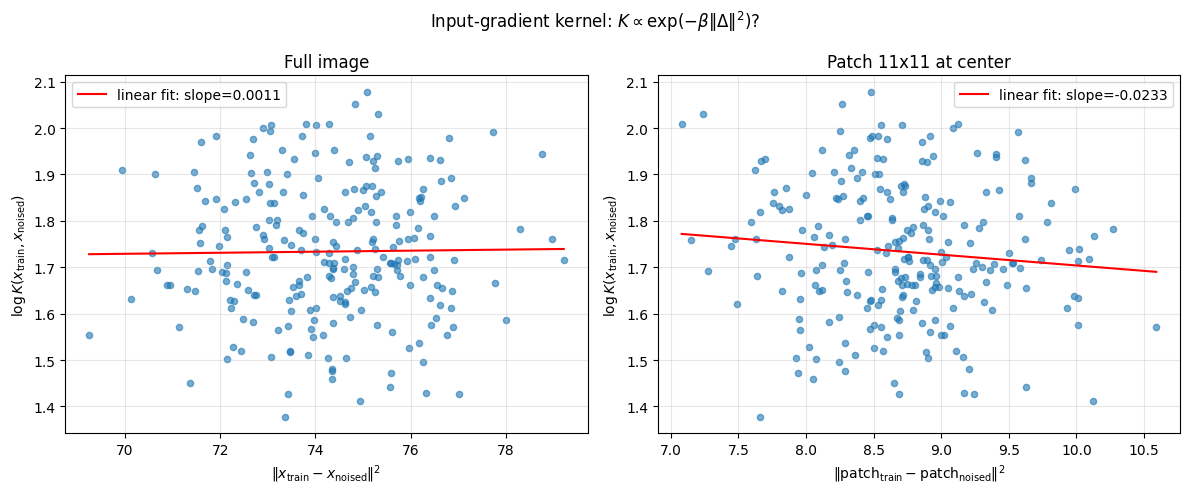

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Full image squared distance
axes[0].scatter(D2_full, log_K, alpha=0.6, s=20)
axes[0].set_xlabel(r"$\|x_{\mathrm{train}} - x_{\mathrm{noised}}\|^2$")
axes[0].set_ylabel(r"$\log K(x_{\mathrm{train}}, x_{\mathrm{noised}})$")
axes[0].set_title("Full image")
if np.isfinite(log_K).all() and np.isfinite(D2_full).all():
    coef = np.polyfit(D2_full, log_K, 1)
    xline = np.linspace(D2_full.min(), D2_full.max(), 100)
    axes[0].plot(xline, np.polyval(coef, xline), "r-", label=f"linear fit: slope={coef[0]:.4f}")
    axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Patch squared distance
axes[1].scatter(D2_patch, log_K, alpha=0.6, s=20)
axes[1].set_xlabel(r"$\|\mathrm{patch}_{\mathrm{train}} - \mathrm{patch}_{\mathrm{noised}}\|^2$")
axes[1].set_ylabel(r"$\log K(x_{\mathrm{train}}, x_{\mathrm{noised}})$")
axes[1].set_title(f"Patch {patch_size}x{patch_size} at center")
if np.isfinite(log_K).all() and np.isfinite(D2_patch).all():
    coef = np.polyfit(D2_patch, log_K, 1)
    xline = np.linspace(D2_patch.min(), D2_patch.max(), 100)
    axes[1].plot(xline, np.polyval(coef, xline), "r-", label=f"linear fit: slope={coef[0]:.4f}")
    axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(r"Input-gradient kernel: $K \propto \exp(-\beta \|\Delta\|^2)$?")
plt.tight_layout()
(ROOT / "results" / "ntk").mkdir(parents=True, exist_ok=True)
plt.savefig(ROOT / "results" / "ntk" / "ntk_vs_sqdist.pdf", bbox_inches="tight")
plt.show()

If the hypothesis holds, the red line slope should be negative (≈ \(-\beta\)). A more negative slope means the kernel decays faster with distance.

## Fit a linear combination of patch L2² to the NTK

Fit \(\log K \approx c_0 + \sum_k c_k \, \|\text{patch}_k(x) - \text{patch}_k(x')\|^2\) and report the coefficients \(c_k\) for each patch size \(k\).

Fitted: log(K) = c0 + sum_k c_k * D2_k
  c0 (intercept) = 1.947925
  c_3 (patch size 3) = 0.043518
  c_5 (patch size 5) = -0.103151
  c_7 (patch size 7) = 0.043873
  c_9 (patch size 9) = -0.032565
  c_11 (patch size 11) = -0.002721

R² = 0.0327


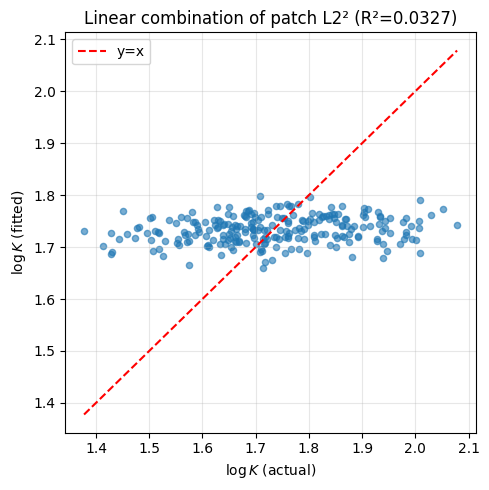

In [12]:
# Design matrix: columns = [1, D2 at size 3, D2 at size 5, ...]
X = np.column_stack([np.ones(len(log_K)), D2_by_size])
y = log_K
# Least squares: X @ coef = y
coef, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
c0, c_by_size = coef[0], coef[1:]

print("Fitted: log(K) = c0 + sum_k c_k * D2_k")
print(f"  c0 (intercept) = {c0:.6f}")
for k, ck in zip(patch_sizes_fit, c_by_size):
    print(f"  c_{k} (patch size {k}) = {ck:.6f}")

log_K_pred = X @ coef
r2 = 1 - np.sum((y - log_K_pred) ** 2) / np.sum((y - y.mean()) ** 2)
print(f"\nR² = {r2:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.scatter(log_K, log_K_pred, alpha=0.6, s=20)
ax.plot([log_K.min(), log_K.max()], [log_K.min(), log_K.max()], "r--", label="y=x")
ax.set_xlabel(r"$\log K$ (actual)")
ax.set_ylabel(r"$\log K$ (fitted)")
ax.set_title(f"Linear combination of patch L2² (R²={r2:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Generated images from the trained ResNet

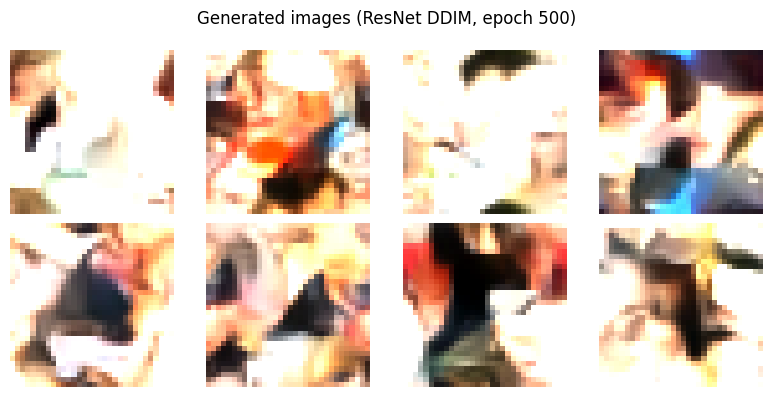

In [13]:
n_gen = 8
with torch.no_grad():
    gen = model.sample(batch_size=n_gen, nsteps=20, device=device)
gen = gen.cpu()
# Denormalize: data was Normalize(mean=0.5, std=0.5) -> [-1,1]; map to [0,1] for display
gen_display = (gen + 1).clamp(0, 1)

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
axes = axes.flatten()
for i in range(n_gen):
    axes[i].imshow(gen_display[i].permute(1, 2, 0).numpy())
    axes[i].set_axis_off()
plt.suptitle(f"Generated images (ResNet DDIM, epoch {selected_epoch})")
plt.tight_layout()
plt.show()

Using 500 training images for NTK posterior.
K_train_train shape: (500, 500), D2_train_train shape: (500, 500)
KL(P_kernel || P_patch): mean=21.1611, std=1.4912, min=16.7412, max=22.6771


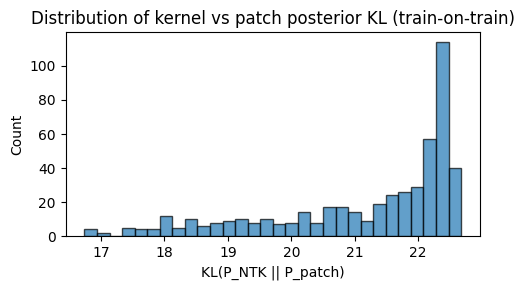

In [16]:
# NTK posterior vs patch posterior (on-the-fly computation)

import numpy as np
import torch
import torch.nn.functional as F

# This cell assumes the following are already defined in the notebook:
# - model: DDIM with ResNet backbone
# - train_set: training dataset
# - device: torch.device
# - t_scalar: time in [0,1]
# - pixel_i, pixel_j: pixel index we differentiate w.r.t.
# - patch_size: odd patch size used for local distances
# - grad_score_single_pixel(model, x, t_scalar, pixel_i, pixel_j): returns ∇_x f(x) flattened

N_train = 500  # keep small so K^{-1} is cheap
lambda_reg = 1e-6
beta_patch = 1.0
eps = 1e-12

# 1. Sample a small subset of training images
torch.manual_seed(0)
idx = torch.randperm(len(train_set))[:N_train]
xs = []
for i in idx.tolist():
    x, *_ = train_set[i]
    xs.append(x.unsqueeze(0))  # (1, C, H, W)
xs = torch.cat(xs, dim=0).to(device)  # (N_train, C, H, W)

print(f"Using {N_train} training images for NTK posterior.")

# 2. Compute input gradients at the chosen pixel for each training image
grads = []
for n in range(N_train):
    x = xs[n : n + 1]  # (1, C, H, W)
    g = grad_score_single_pixel(model, x, t_scalar, pixel_i, pixel_j)
    grads.append(g.view(-1))

grads = torch.stack(grads, dim=0).cpu().numpy()  # (N_train, D)

# Gram matrix K_train_train
K_train_train = grads @ grads.T  # (N_train, N_train)

# 3. Patch-restricted squared distances between all training images
assert patch_size % 2 == 1
r = patch_size // 2

xs_cpu = xs.cpu()
N, C, H, W = xs_cpu.shape

# Pad and extract patches around (pixel_i, pixel_j)
xs_pad = F.pad(xs_cpu, (r, r, r, r), mode="constant", value=0.0)
pi = pixel_i + r
pj = pixel_j + r
patches = xs_pad[:, :, pi - r : pi + r + 1, pj - r : pj + r + 1].reshape(N, -1)  # (N, D_patch)

# Pairwise squared patch distances
# D2_train_train[i,j] = ||patch_i - patch_j||^2
with torch.no_grad():
    diff = patches[:, None, :] - patches[None, :, :]
    D2_train_train = (diff ** 2).sum(-1).cpu().numpy()

print(
    f"K_train_train shape: {K_train_train.shape}, "
    f"D2_train_train shape: {D2_train_train.shape}"
)

# For this analysis we treat the same set as both "train" and "test"
K_train_test = K_train_train.copy()      # (N_train, N_train)
D2_train_test = D2_train_train.copy()    # (N_train, N_train)
N_test = N_train

# 4. Kernel posterior p_NTK(i | x_j)
# For each test point x_j, k(x_j, ·) is the j-th column of K_train_test.
# We compute alpha(x_j) = K^{-1} k(x_j, ·) and interpret alpha as a (clipped) posterior.

K_reg = K_train_train + lambda_reg * np.eye(N_train, dtype=K_train_train.dtype)
K_inv = np.linalg.inv(K_reg)

# alpha(x_j) for all j at once: W[j, i] = alpha_i(x_j)
W = (K_inv @ K_train_test).T  # (N_test, N_train)

# Clip to non-negative and normalize row-wise
W_clipped = np.maximum(W, 0.0)
P_kernel = W_clipped / (W_clipped.sum(axis=1, keepdims=True) + eps)  # (N_test, N_train)

# 5. Patch posterior p_patch(i | x_j) from patch L2^2
# Gibbs posterior: p_patch(i | x_j) ∝ exp(-beta_patch * ||patch_i - patch_j||^2)

log_k_patch = -beta_patch * D2_train_test.T  # (N_test, N_train)
log_k_patch -= log_k_patch.max(axis=1, keepdims=True)  # stabilize
K_patch = np.exp(log_k_patch)
P_patch = K_patch / (K_patch.sum(axis=1, keepdims=True) + eps)

assert P_kernel.shape == P_patch.shape

# 6. KL divergence KL(P_kernel || P_patch)

kl = np.sum(P_kernel * (np.log(P_kernel + eps) - np.log(P_patch + eps)), axis=1)
print(
    f"KL(P_kernel || P_patch): "
    f"mean={kl.mean():.4f}, std={kl.std():.4f}, "
    f"min={kl.min():.4f}, max={kl.max():.4f}"
)

plt.figure(figsize=(5, 3))
plt.hist(kl, bins=30, alpha=0.7, edgecolor="k")
plt.xlabel("KL(P_NTK || P_patch)")
plt.ylabel("Count")
plt.title("Distribution of kernel vs patch posterior KL (train-on-train)")
plt.tight_layout()
plt.show()
